### Coupled two-channel analysis: Background and poles

We consider the two-channel S-matrix satisfying unitarity, hermiticity and analyticity. <br>

<br>
\begin{equation}
S_{11}=\dfrac{D(-p_1,p_2)}{D(p_1,p_2)};\quad
S_{22}=\dfrac{D(p_1,-p_2)}{D(p_1,p_2)};\quad\mbox{and}\quad
\mbox{det }S = \dfrac{D(-p_1,-p_2)}{D(p_1,p_2)}
\end{equation}
<br>
where $D(p_1,p_2)$ will determine the pole position and the Riemann sheet. Background will also be incorporated inside $D(p_1,p_2)$. <br>

The channel momentum $p_n$ is given by the relativistic expression:
<br>
\begin{equation}
p_n=\sqrt{\dfrac{(s-(m_{n1}+m_{n2})^2)(s-(m_{n1}-m_{n2})^2)}{4s}}.
\end{equation}
<br>
We are only interested in the region near the threshold. It will suffice to utilize the simplified momentum:
\begin{equation}
q_n^2=s-(m_{n1}+m_{n2})^2.
\end{equation}
<br>

Initialize:

In [1]:
import numpy as np
import cmath as cm
import pandas as pd
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
import matplotlib.pyplot as plt
from utils import utils_ml
import matplotlib.pyplot as plt


####################################
#Units in MeV
# constants
hbarc = 197.3
# Heavy quark sector
# Units in MeV
JPsi = 3096.90
Proton = 938.27208816
Dplus = 1869.66
Dbar0 = 1864.83
Sigmaplus = 1189.37
Sigmaplus_C = 2452.9

# Define thresholds
T1 = (JPsi + Proton)/hbarc
T2 = (Sigmaplus_C + Dbar0)/hbarc
T4 = 4350/hbarc

NEpoints = 1500
#Generate energy axis 
Einput = []
delE = (T2 - T1 + 500/197.3)*197.3/(NEpoints)
for ndx in range(NEpoints):
    Einput.append(np.random.uniform(low=T1*197.3+(ndx)*delE, high=T1*197.3+(ndx+1)*delE))
Einput = np.array(Einput)             
#vectorize function evaluation
q1 = np.sqrt(Einput**2.0-(T1*197.3)**2.0)
q2 = []
#cmath can't take array input.
for kndx in range(len(Einput)):
    q2.append(cm.sqrt(Einput[kndx]**2.0-(T1*197.3)**2.0))
q2 = np.asarray(q2)

We use the uniformized parametrization to generate the poles. <br>
Introduce uniformized parameter: $\omega=\dfrac{p_1+p_2}{\sqrt{\epsilon_2^2-\epsilon_1^2}}$ (linear form eliminates the production of extra pole) <br>
Background can be represented by distant uniformized poles; $Re E_{pole}<<T_1$ .

In [2]:
#Class that takes the input Riemann sheet and pole position.
#The regulator pole is automatically calculated.
#The S-matrix contribution of the input pole is obtained by the calling the method .smat11 and .smat22

class unif_pole:
    def __init__(self, RS, Ereal, Eimag):
        #RS is the two-channel Reimann sheet location of the pole
        #Use [-1,1] for bt, [-1,-1] for bb and [1,-1] for tb
        
        #Ereal is the real part of energy pole
        #Eimag is the imag part of energy pole
        Epole = Ereal - (1j)*Eimag
        self.pos = Epole
        #compute uniformized momentum pole
        #for channel 1 and channel 2
        k1pole = cm.sqrt((Epole/197.3)**2-T1**2)
        k2pole = cm.sqrt((Epole/197.3)**2-T2**2)
        #Assign Riemann sheet
        beta1  = RS[0]*abs(k1pole.imag)
        beta2  = RS[1]*abs(k2pole.imag)
        #Get the real part, we need to be consistent with signs
        alpha1 = -np.sign(beta1)*np.abs(k1pole.real)
        alpha2 = -np.sign(beta2)*np.abs(k2pole.real)

        #Just for counterchecking
        #signs of beta1 and beta2 should agree 
        #with RS[0] and RS[1], respectively
        self.alpha1 = alpha1
        self.alpha2 = alpha2
        self.beta1 = beta1
        self.beta2 = beta2
        
        #Construct pole channel momenta
        polep1 = (1j)*beta1 + alpha1
        polep2 = (1j)*beta2 + alpha2
        
        Delta = cm.sqrt(T2**2 - T1**2)
        self.Delta = Delta
        
        #Perfrom uniformization of the assigned pole
        omega_pole = (polep1 + polep2)/Delta
        recip_omg_pol = 1/omega_pole
        self.omega_pole = omega_pole
        self.recip_omg_pol = recip_omg_pol
        
        #Get pole regulator
        #[bt] sheet
        if RS==[-1,1]: 
            omega_reg = np.abs(recip_omg_pol)*cm.exp(-0.5*np.pi*(1j))
        #[bb] sheet
        elif RS==[-1,-1]:
            omega_reg = np.abs(recip_omg_pol)*cm.exp(-0.5*np.pi*(1j))
        #[tb] sheet
        elif RS==[1,-1]:
            omega_reg = np.abs(recip_omg_pol)*cm.exp(-0.5*np.pi*(1j))
            
        self.omega_reg = omega_reg
        self.recip_omg_reg = 1/omega_reg
        
        p1_reg = omega_reg + 1/omega_reg
        p2_reg = omega_reg - 1/omega_reg
        
        #Riemann sheet identifier for pole regulator
        def RSlabel(pimag1, pimag2):
            if pimag1>0 and pimag2>0:
                RS = 'tt'
            elif pimag1<0 and pimag2>0:
                RS = 'bt'
            elif pimag1<0 and pimag2<0:
                RS = 'bb'
            elif pimag1>0 and pimag2<0:
                RS = 'tb'
            return RS
        #If you want to check the Riemann sheet of pole regulator
        self.regulator = ['{:.2f}'.format(np.sqrt(p1_reg**2.0+T1**2.0)*197.3), RSlabel(p1_reg.imag, p2_reg.imag)]
        self.assignedpole = ['{:.2f}'.format(np.sqrt(polep1**2.0+T1**2.0)*197.3), RSlabel(polep1.imag, polep2.imag)]
        self.input = ['{:.2f}'.format(Epole), RSlabel(polep1.imag, polep2.imag)]
    
    #The indent on this part is very important
    #Claculate the S-matrix contribution of the uniformized pole
    def smat11(self, Ecm):
        #Get channel momenta of Ecm
        #vectorize function evaluation
        p1 = np.sqrt((Ecm/197.3)**2.0-T1**2.0)
        #cmath cannot take array input
        #we use the almighty for loop to vectorize p2
        p2 = []
        for pndx in range(len(Ecm)):
            p2.append(cm.sqrt((Ecm[pndx]/197.3)**2.0-T2**2.0))
        p2 = np.asarray(p2)

        #Get uniformized parameter
        omega = (p1 + p2)/self.Delta
        #Numerator of S-matrix
        Numpol = (omega-np.conj(self.recip_omg_pol))*(omega+self.recip_omg_pol)
        Numreg = (omega-np.conj(self.recip_omg_reg))*(omega+self.recip_omg_reg)
        Num = Numpol*Numreg
        #Denominator of S-matrix
        Denpol = (omega-self.omega_pole)*(omega+np.conj(self.omega_pole))
        Denreg = (omega-self.omega_reg)*(omega+np.conj(self.omega_reg))
        Den = Denpol*Denreg
            
        return np.abs(1/(self.omega_pole*self.omega_reg))**2.0*Num/Den
    
    def smat22(self, Ecm):
        #Get channel momenta of Ecm
        #vectorize function evaluation
        p1 = np.sqrt((Ecm/197.3)**2.0-T1**2.0)
        #cmath cannot take array input
        #we use the almighty for loop to vectorize p2
        p2 = []
        for pndx in range(len(Ecm)):
            p2.append(cm.sqrt((Ecm[pndx]/197.3)**2.0-T2**2.0))
        p2 = np.asarray(p2)

        #Get uniformized parameter
        omega = (p1 + p2)/self.Delta
        #Numerator of S-matrix
        Numpol = (omega+np.conj(self.recip_omg_pol))*(omega-self.recip_omg_pol)
        Numreg = (omega+np.conj(self.recip_omg_reg))*(omega-self.recip_omg_reg)
        Num = Numpol*Numreg
        #Denominator of S-matrix
        Denpol = (omega-self.omega_pole)*(omega+np.conj(self.omega_pole))
        Denreg = (omega-self.omega_reg)*(omega+np.conj(self.omega_reg))
        Den = Denpol*Denreg
            
        return np.abs((self.omega_pole*self.omega_reg))**2.0*Num/Den

In the following codes, we will create an object called pole and plot the corresponding elastic cross-sections.<br>
Note that the Riemann sheets should take:<br>
Sheet 2 (bt): [-1,1] <br>
Sheet 3 (bb): [-1,-1] <br>
Sheet 4 (tb): [1,-1] <br>

### Three-pole structure: ambigous case

In [6]:
#Add extra poles in the 3rd and 4th Riemann sheets
pole1 = unif_pole([-1,1],T2*197.3-10.0,50)
pole2 = unif_pole([-1,-1],T2*197.3-10.0,50)
pole3 = unif_pole([1,-1],T2*197.3-10.0,50)

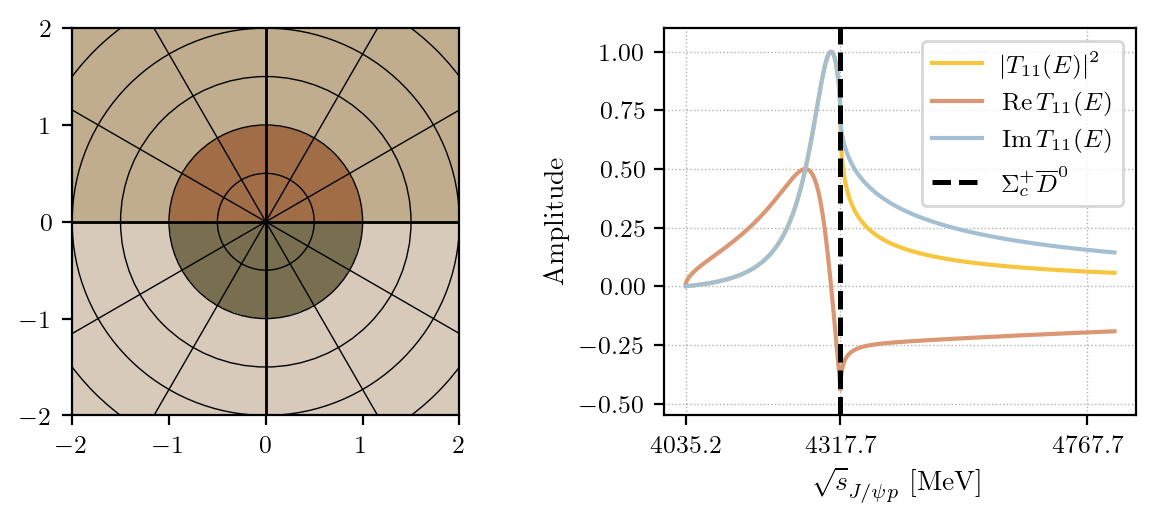

In [ ]:
# Create the combined figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6.15, 2.75))

# ===== LEFT SUBPLOT: Circle plot =====
# Set the limits
ax1.set_xlim(-2, 2)
ax1.set_ylim(-2, 2)

# Create meshgrid
x = np.linspace(-3, 3, 500)
y = np.linspace(-3, 3, 500)
X, Y = np.meshgrid(x, y)
R = np.sqrt(X**2 + Y**2)
Theta = np.arctan2(Y, X)

# Define colors
colors = {
    "top_inner": "#A16D47",      # Muted clay (warm, earthy orange-brown)  
    "bottom_inner": "#776F4F",   # Toasted almond (subtle tan/golden beige)
    "top_outer": "#C0AD8D",      # Sage green (natural, calming)
    "bottom_outer": "#D8CABA"    # Olive green (deep, grounding)
}

# Define regions by angle and radius with appropriate colors
regions = [
    ((R <= 1) & (Y >= 0), colors["top_inner"]),      # top inner
    ((R <= 1) & (Y < 0), colors["bottom_inner"]),     # bottom inner
    ((R > 1) & (R <= 3) & (Y >= 0), colors["top_outer"]),  # top outer
    ((R > 1) & (R <= 3) & (Y < 0), colors["bottom_outer"])       # bottom outer
]

# Plot each region
for mask, color in regions:
    ax1.contourf(X, Y, mask, levels=[0.5, 1], colors=[color])

# Draw radial grid lines (black)
for angle in np.linspace(0, 2 * np.pi, 12, endpoint=False):
    ax1.plot([0, 3 * np.cos(angle)], [0, 3 * np.sin(angle)], color='black', lw=0.5)

# Draw concentric circles (black)
for r in np.linspace(0.5, 3, 6):
    circle = plt.Circle((0, 0), r, color='black', fill=False, lw=0.5)
    ax1.add_artist(circle)

# Draw x and y axes
ax1.axhline(0, color='black', lw=1)
ax1.axvline(0, color='black', lw=1)

# Set integer ticks
ticks = [-2, -1, 0, 1, 2]
ax1.set_xticks(ticks)
ax1.set_yticks(ticks)
ax1.tick_params(labelsize=9)

# Set equal aspect ratio
ax1.set_aspect('equal')

# Add axis labels for consistency
# ax1.set_xlabel('X', fontsize=10)
# ax1.set_ylabel('Y', fontsize=10)

# ===== RIGHT SUBPLOT: Line plot =====
# Compute scattering amplitude (assuming you have the data)
onepole_S11 = pole1.smat11(Einput)
onepole_T11 = (onepole_S11 - 1.0) / (2.0 * 1j)

# Energy range to display
strt = 1
end = NEpoints

# Constants for labeling
threshold_energy = T2 * 197.3

# Plot settings
ax2.set_ylim(-0.55, 1.1)

# Plot components of the amplitude
ax2.plot(Einput[strt:end], abs(onepole_T11[strt:end])**2, '#F6C63F', lw=1.5, label=r'$|T_{11}(E)|^2$')
ax2.plot(Einput[strt:end], onepole_T11[strt:end].real, '#D99873', lw=1.5, label=r'$\mathrm{Re}\,T_{11}(E)$')
ax2.plot(Einput[strt:end], onepole_T11[strt:end].imag, '#A5BFD2', lw=1.5, label=r'$\mathrm{Im}\,T_{11}(E)$')
ax2.axvline(x=threshold_energy, color='k', linestyle='--', lw=1.8, label=r'$\Sigma_c^+ \overline{D}^0$')

	
# Axis and ticks
ax2.set_xlabel(r'$\sqrt{s}_{J/\psi p}$ [MeV]', fontsize=10)
ax2.set_ylabel(r'Amplitude ', fontsize=10)
ax2.set_xticks([T1 * 197.3, T2 * 197.3, T2 * 197.3 + 450.0])
ax2.tick_params(labelsize=9)

# Legend
ax2.legend(loc='upper right', fontsize=9, frameon=True)

# Grid
ax2.grid(True, linestyle=':', linewidth=0.5)

# Adjust spacing between subplots
plt.subplots_adjust(wspace=0.3)

# Save and show
plt.tight_layout()
# plt.savefig("combined_figure.png", dpi=800, transparent=True, bbox_inches='tight', pad_inches=0.1)
plt.show()